# Final 2: optimizations on top of final

- every extra optimization the project developed, one section each, portable into final one at a time
- optimizations: 1 decay selection, 2 change targets, 3 residual correction, 4 compact spillover, 5 two-stage tuning, 6 EWA combination, 7 full holdout evaluation, 8 honest statistics (corrected DA, DM tests, BH, reality check), 9 weighted directional accuracy, 10 stress periods
- disclosure: this evaluation period was examined during development, the forward test section at the end is the clean confirmation
- concepts explained in final2_explained.md

In [1]:
from gaussian_hsmm import GaussianHSMM
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/FRB_H15.csv").dropna()

#rename columns
df.rename(columns={"Series Description": "Date", "Market yield on U.S. Treasury securities at 1-month  constant maturity, quoted on investment basis": "0Y1M", "Market yield on U.S. Treasury securities at 3-month  constant maturity, quoted on investment basis": "0Y3M", "Market yield on U.S. Treasury securities at 6-month  constant maturity, quoted on investment basis": "0Y6M", "Market yield on U.S. Treasury securities at 1-year  constant maturity, quoted on investment basis": "1Y", "Market yield on U.S. Treasury securities at 2-year  constant maturity, quoted on investment basis": "2Y", "Market yield on U.S. Treasury securities at 3-year  constant maturity, quoted on investment basis": "3Y", "Market yield on U.S. Treasury securities at 5-year  constant maturity, quoted on investment basis": "5Y", "Market yield on U.S. Treasury securities at 7-year  constant maturity, quoted on investment basis": "7Y", "Market yield on U.S. Treasury securities at 10-year  constant maturity, quoted on investment basis": "10Y", "Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis": "20Y", "Market yield on U.S. Treasury securities at 30-year  constant maturity, quoted on investment basis": "30Y"}, inplace=True)
df.rename(columns={"Market yield on U.S. Treasury securities at 20-year  constant maturity, quoted on investment basis": "20Y"}, inplace=True)

#make index to datetime for timeseries
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

matList = ["0Y1M", "0Y3M", "0Y6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
df = df[matList].apply(pd.to_numeric, errors="coerce").dropna()

BE5 = pd.read_csv("../data/T5YIE.csv").dropna()
BE5.rename(columns={"observation_date": "Date", "T5YIE": "BE5"}, inplace=True)
BE5["Date"] = pd.to_datetime(BE5["Date"])
BE5.set_index("Date", inplace=True)

EFFR = pd.read_csv("../data/EFFR.csv").dropna()
EFFR.rename(columns={"observation_date": "Date"}, inplace=True)
EFFR["Date"] = pd.to_datetime(EFFR["Date"])
EFFR.set_index("Date", inplace=True)

rates = df[["2Y"]].merge(EFFR[["EFFR"]], left_index=True, right_index=True, how="left")
rates = rates.apply(pd.to_numeric, errors="coerce")
rates["policy_spread"] = rates["2Y"] - rates["EFFR"]

spill = pd.read_csv("../data/spillover_features.csv", parse_dates=["date"])
spill.set_index("date", inplace=True)

maturityYears = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
horizons = [1, 5, 20]

print("yields: ", len(df), " spillover days: ", len(spill))

yields:  6199  spillover days:  5947


#### Optimization 1: decay selection

- fits factors per day by least squares for a grid of decay values (same math as NelsonSiegel.ipynb)
- keeps the decay with the best curve fit on the first 80% only
- saves the residuals (observed minus fitted yield) for optimization 3

In [3]:
def buildLoadings(decay):
    rows = []
    for t in maturityYears:
        L = 1
        S = (1 - np.exp(-decay * t)) / (decay * t)
        C = S - np.exp(-decay * t)
        rows.append([L, S, C])
    return np.array(rows)


def estimateFactors(yieldFrame, decay):
    #per day least squares fit, day t factors only use day t yields
    loadings = buildLoadings(decay)
    projection = np.linalg.pinv(loadings)
    factorArray = yieldFrame.to_numpy() @ projection.T
    reconstructed = factorArray @ loadings.T
    factorsDf = pd.DataFrame(factorArray, index=yieldFrame.index, columns=["level", "slope", "curvature"])
    residualsDf = yieldFrame - pd.DataFrame(reconstructed, index=yieldFrame.index, columns=matList)
    return factorsDf, residualsDf, loadings


#align on everything the pipeline needs, then keep the first 80% for the decay choice
aligned = df.merge(BE5[["BE5"]], left_index=True, right_index=True, how="inner")
aligned = aligned.merge(rates[["policy_spread"]], left_index=True, right_index=True, how="inner")
aligned = aligned.merge(spill[["total_connectedness"]], left_index=True, right_index=True, how="inner")
aligned = aligned.dropna()

decayTrainEnd = int(0.8 * len(aligned))
decayTrainDates = aligned.index[:decayTrainEnd]

bestDecay = None
bestFitRmse = np.inf
for decay in np.arange(0.02, 0.801, 0.005):
    factorsTemp, residualsTemp, loadingsTemp = estimateFactors(df.loc[decayTrainDates], decay)
    fitRmse = np.sqrt(np.mean(residualsTemp.to_numpy() ** 2))
    if fitRmse < bestFitRmse:
        bestFitRmse = fitRmse
        bestDecay = decay

dns, residuals, A = estimateFactors(df, bestDecay)
print("selected decay: ", round(bestDecay, 4), " (classic value 0.0609 assumes month units, ours are years)")
print("training curve fit rmse: ", round(100 * bestFitRmse, 2), " bp")
print("decay chosen using data through: ", decayTrainDates[-1].date())

selected decay:  0.485  (classic value 0.0609 assumes month units, ours are years)
training curve fit rmse:  8.12  bp
decay chosen using data through:  2021-09-08


#### HSMM regime features (causal filter)

- fits the 3-state HSMM on the first 80% of this notebook's own factors (standalone from final)
- causal forward filter: day t probabilities use only data through t
- outputs: 3 filtered probabilities, confidence, entropy, expected remaining duration

In [4]:
hsmmFeatures = ["level", "slope", "curvature", "BE5", "policy_spread"]

combined = dns.merge(BE5[["BE5"]], left_index=True, right_index=True, how="inner")
combined = combined.merge(rates[["policy_spread"]], left_index=True, right_index=True, how="inner")
combined = combined[hsmmFeatures].apply(pd.to_numeric, errors="coerce").dropna().sort_index()

hsmmSplit = int(0.8 * len(combined))
hsmmTrainDf = combined.iloc[:hsmmSplit]

hsmmScaler = StandardScaler()
xHsmmTrain = hsmmScaler.fit_transform(hsmmTrainDf)
xHsmmAll = hsmmScaler.transform(combined)

hsmmModel = GaussianHSMM(
    n_components = 3,
    covariance_type = "diag",
    max_duration = 126,
    n_iter = 6,
    hmm_n_iter = 500,
    tol = 1e-3,
    min_covar = 1e-4,
    random_state = 42,
)
hsmmModel.fit(xHsmmTrain)


def gaussianLogLikelihood(observations, means, variances):
    logLik = np.empty((len(observations), len(means)))
    for state in range(len(means)):
        stateVar = np.maximum(variances[state], 1e-12)
        squaredDist = (observations - means[state]) ** 2 / stateVar
        logLik[:, state] = -0.5 * np.sum(np.log(2.0 * np.pi * stateVar) + squaredDist, axis=1)
    return logLik


def causalHsmmFilter(model, observations):
    numStates = model.n_components
    maxDuration = model.max_duration
    durations = np.arange(1, maxDuration + 1)
    logEmissions = gaussianLogLikelihood(observations, model.means_, model.covars_)
    durationProbs = model.duration_probs_[:, 1 : maxDuration + 1]

    filteredProbs = np.zeros((len(observations), numStates))
    expectedRemaining = np.zeros(len(observations))
    expanded = model.startprob_[:, None] * durationProbs

    for t in range(len(observations)):
        if t > 0:
            predicted = np.zeros((numStates, maxDuration))
            predicted[:, :-1] = predicted[:, :-1] + expanded[:, 1:]
            finishedMass = expanded[:, 0]
            enteringMass = finishedMass @ model.transmat_
            predicted = predicted + enteringMass[:, None] * durationProbs
            expanded = predicted

        scaledEmission = np.exp(logEmissions[t] - logEmissions[t].max())
        expanded = expanded * scaledEmission[:, None]
        total = expanded.sum()
        assert total > 0.0 and np.isfinite(total)
        expanded = expanded / total
        filteredProbs[t] = expanded.sum(axis=1)
        expectedRemaining[t] = np.sum(expanded * durations[None, :])

    return filteredProbs, expectedRemaining


filteredProbs, expectedRemaining = causalHsmmFilter(hsmmModel, xHsmmAll)
assert np.allclose(filteredProbs.sum(axis=1), 1.0)

regime = pd.DataFrame(index=combined.index)
regime["state_0_prob"] = filteredProbs[:, 0]
regime["state_1_prob"] = filteredProbs[:, 1]
regime["state_2_prob"] = filteredProbs[:, 2]
regime["state_confidence"] = filteredProbs.max(axis=1)
safeProbs = np.clip(filteredProbs, 1e-12, 1.0)
regime["state_entropy"] = -np.sum(safeProbs * np.log(safeProbs), axis=1)
regime["expected_remaining"] = expectedRemaining
print("hsmm trained through: ", hsmmTrainDf.index[-1].date())

hsmm trained through:  2021-09-08


#### Optimization 4: compact spillover features and the modeling table

- averages the 11 net transmission inputs into short / belly / long regions plus 5 day changes
- builds the aligned modeling table and aligns yields and residuals to it
- evaluation windows = every day after the last training-only design boundary with a valid 20 day target (1100+ windows)

In [5]:
compact = pd.DataFrame(index=spill.index)
compact["total_connectedness"] = spill["total_connectedness"]
compact["maximum_edge"] = spill["maximum_edge"]
compact["average_absolute_net"] = spill["average_absolute_net"]
compact["short_net"] = spill[["net_0Y1M", "net_0Y3M", "net_0Y6M", "net_1Y"]].mean(axis=1)
compact["belly_net"] = spill[["net_2Y", "net_3Y", "net_5Y", "net_7Y"]].mean(axis=1)
compact["long_net"] = spill[["net_10Y", "net_20Y", "net_30Y"]].mean(axis=1)
compact["long_minus_short"] = compact["long_net"] - compact["short_net"]
compact["connectedness_change_5d"] = compact["total_connectedness"].diff(5)
compact["long_net_change_5d"] = compact["long_net"].diff(5)

spilloverFeatures = ["total_connectedness", "maximum_edge", "average_absolute_net", "short_net", "belly_net", "long_net", "long_minus_short", "connectedness_change_5d", "long_net_change_5d"]
regimeFeatures = ["state_0_prob", "state_1_prob", "state_2_prob", "state_confidence", "state_entropy", "expected_remaining"]

modelDf = dns.merge(regime, left_index=True, right_index=True, how="inner")
modelDf = modelDf.merge(compact, left_index=True, right_index=True, how="inner")
modelDf = modelDf.dropna().sort_index()

yields = df.loc[modelDf.index]
residualsAligned = residuals.loc[modelDf.index]

#holdout starts after the LAST training-only design decision
boundaries = [hsmmTrainDf.index[-1], decayTrainDates[-1]]
with open("../data/generated/spillover_design_boundary.txt") as f:
    boundaries.append(pd.Timestamp(f.read().strip()))
holdoutStart = int(modelDf.index.searchsorted(max(boundaries), side="right"))

windowStarts = []
for position in range(holdoutStart, len(modelDf) - 20):
    windowStarts.append(position)

print("aligned days: ", len(modelDf))
print("holdout starts: ", modelDf.index[holdoutStart].date())
print("evaluation windows: ", len(windowStarts))

aligned days:  5841
holdout starts:  2021-09-09
evaluation windows:  1149


#### Optimizations 2 and 3: change targets and residual correction

- predictors built once with shift: current factor levels plus 1-4 day changes, regime features, compact spillover
- targets are factor CHANGES from t to t+h
- forecastResiduals: AR(1) per maturity on the DNS fit residuals, trailing 1000 days, refit per window
- varxForecast = loadings @ (current factors + predicted change) + predicted residuals

In [6]:
predictors = pd.DataFrame(index=modelDf.index)
for factor in ["level", "slope", "curvature"]:
    predictors[factor + "_current"] = modelDf[factor]
    predictors[factor + "_change_1d"] = modelDf[factor].diff(1)
    predictors[factor + "_change_2d"] = modelDf[factor].diff(2)
    predictors[factor + "_change_3d"] = modelDf[factor].diff(3)
    predictors[factor + "_change_4d"] = modelDf[factor].diff(4)
for feature in regimeFeatures:
    predictors[feature] = modelDf[feature]
for feature in spilloverFeatures:
    predictors[feature] = modelDf[feature]

featureNames = list(predictors.columns)

#change targets, one table per horizon: row t holds factors(t+h) - factors(t)
changeTargets = {}
for horizon in horizons:
    changeTargets[horizon] = modelDf[["level", "slope", "curvature"]].shift(-horizon) - modelDf[["level", "slope", "curvature"]]


def makeTrainingSlice(horizon, start, windowLength):
    #a training row at day o is allowed only if its target day o+h is known by the window start
    lastTrain = start - horizon
    firstTrain = 4
    if windowLength is not None:
        firstTrain = max(firstTrain, lastTrain - windowLength + 1)
    xTrain = predictors.iloc[firstTrain : lastTrain + 1]
    yTrain = changeTargets[horizon].iloc[firstTrain : lastTrain + 1].to_numpy(dtype=float)
    return xTrain, yTrain


def forecastResiduals(start, horizon):
    #AR(1) per maturity on the DNS fit residuals, trailing 1000 days
    forecasts = []
    historyStart = max(0, start - 1000 + 1)
    for mat in matList:
        history = residualsAligned[mat].iloc[historyStart : start + 1].to_numpy()
        lagged = history[:-1]
        current = history[1:]
        design = np.column_stack([np.ones(len(lagged)), lagged])
        coeffs = np.linalg.lstsq(design, current, rcond=None)[0]
        intercept = coeffs[0]
        persistence = np.clip(coeffs[1], -0.99, 0.99)
        if abs(1.0 - persistence) > 1e-8:
            longRunMean = intercept / (1.0 - persistence)
        else:
            longRunMean = history.mean()
        forecasts.append(longRunMean + persistence ** horizon * (history[-1] - longRunMean))
    return np.array(forecasts)


def varxForecast(horizon, start, windowLength, alpha):
    #predicted yield curve = loadings @ (current factors + predicted change) + predicted residuals
    xTrain, yTrain = makeTrainingSlice(horizon, start, windowLength)
    scaler = StandardScaler()
    xTrainScaled = scaler.fit_transform(xTrain)
    model = Ridge(alpha=alpha)
    model.fit(xTrainScaled, yTrain)
    xCurrent = scaler.transform(predictors.iloc[[start]])
    predictedChange = model.predict(xCurrent)[0]
    currentFactors = modelDf[["level", "slope", "curvature"]].iloc[start].to_numpy(dtype=float)
    return A @ (currentFactors + predictedChange) + forecastResiduals(start, horizon)

print("predictors: ", len(featureNames))

predictors:  30


#### Optimization 5: two-stage tuning

- 40 pseudo windows a week apart, ending 20 days before the holdout
- selects training window (504 / 1000 / expanding) and ridge alpha by pure VARX accuracy

In [7]:
lastPseudo = holdoutStart - 20
pseudoStarts = []
for k in range(39, -1, -1):
    pseudoStarts.append(lastPseudo - 5 * k)
assert pseudoStarts[0] > 300

windowGrid = [504, 1000, None]
alphaGrid = [0.1, 1.0, 10.0, 100.0, 1000.0]

bestSettings = {}
for horizon in horizons:
    bestRmse = np.inf
    for windowLength in windowGrid:
        for alpha in alphaGrid:
            errors = []
            for start in pseudoStarts:
                predictedYields = varxForecast(horizon, start, windowLength, alpha)
                actualYields = yields.iloc[start + horizon].to_numpy(dtype=float)
                for error in (predictedYields - actualYields):
                    errors.append(error ** 2)
            rmse = np.sqrt(np.mean(errors))
            if rmse < bestRmse:
                bestRmse = rmse
                bestSettings[horizon] = {"window": windowLength, "alpha": alpha}
    print("horizon ", horizon, " window: ", bestSettings[horizon]["window"], " alpha: ", bestSettings[horizon]["alpha"], " pseudo rmse: ", round(100 * bestRmse, 2), " bp")

horizon  1  window:  None  alpha:  1000.0  pseudo rmse:  2.98  bp


horizon  5  window:  None  alpha:  1000.0  pseudo rmse:  5.48  bp


horizon  20  window:  None  alpha:  1000.0  pseudo rmse:  13.87  bp


#### Optimizations 6 and 7: EWA combination over the full holdout

- runEvaluation: random walk, VARX, and EWA combination at every window
- EWA per day: absorb realized outcomes (window + h <= today) into discounted loss totals, weight = softmax comparison, 1% floor toward 50/50
- plots the weight path per horizon (0 = pure random walk)

finished window  200  of  1149


finished window  400  of  1149


finished window  600  of  1149


finished window  800  of  1149


finished window  1000  of  1149


finished window  1149  of  1149


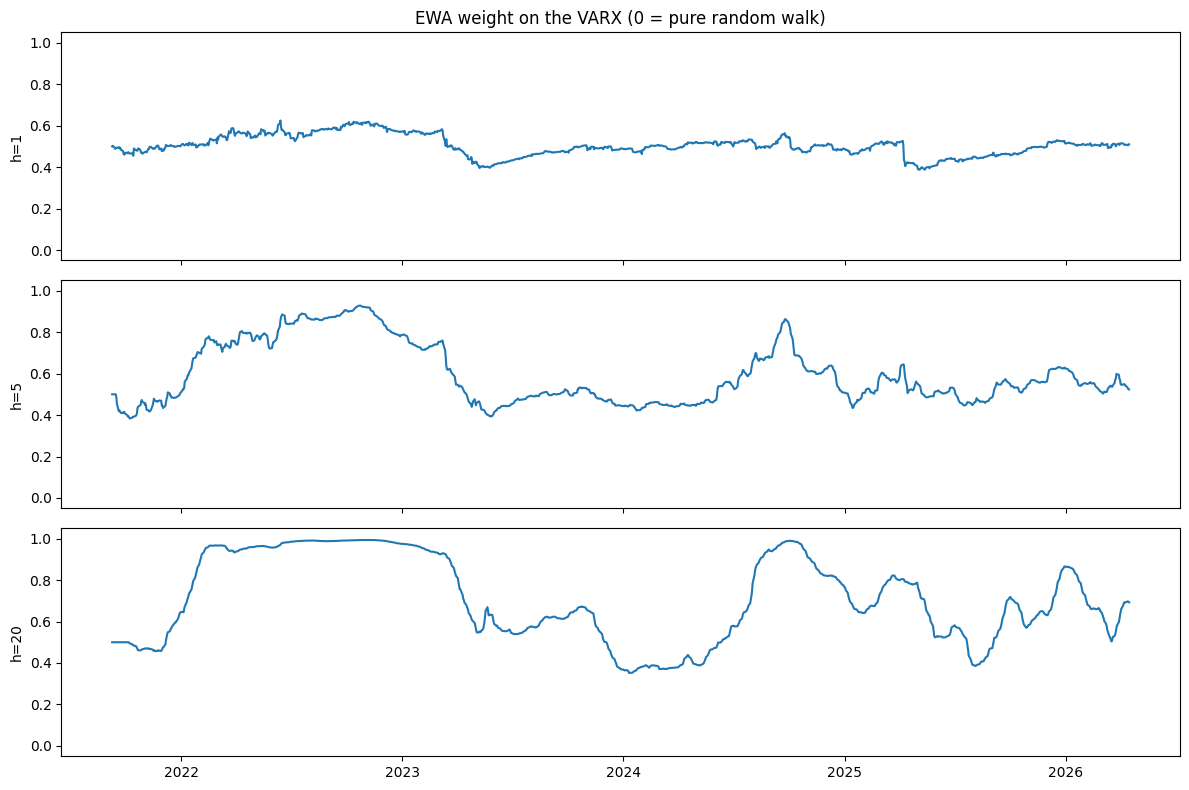

In [8]:
ewaDiscount = 0.99
ewaEta = np.sqrt(8.0 * np.log(2.0) / 100.0)
ewaFloor = 0.01


def runEvaluation(starts, freshEwa=True):
    #returns one dict of forecast arrays per model, indexed like starts
    results = {"Random Walk": [], "VARX": [], "EWA Ensemble": [], "actual": [], "current": [], "weights": []}

    state = {}
    for horizon in horizons:
        state[horizon] = {"varxLossSum": 0.0, "walkLossSum": 0.0, "normSum": 0.0, "normCount": 0.0, "absorbed": 0, "history": []}

    for startIndex in range(len(starts)):
        start = starts[startIndex]
        rowRw = []
        rowVarx = []
        rowEwa = []
        rowActual = []
        rowCurrent = []
        rowWeights = []

        for horizon in horizons:
            settings = bestSettings[horizon]
            varxYields = varxForecast(horizon, start, settings["window"], settings["alpha"])
            walkYields = yields.iloc[start].to_numpy(dtype=float)
            actualYields = yields.iloc[start + horizon].to_numpy(dtype=float)

            #step 1: absorb known outcomes (window + h <= current index)
            s = state[horizon]
            while s["absorbed"] + horizon <= startIndex:
                past = s["history"][s["absorbed"]]
                varxLoss = np.mean((past[2] - past[0]) ** 2)
                walkLoss = np.mean((past[2] - past[1]) ** 2)
                s["normSum"] = ewaDiscount * s["normSum"] + walkLoss
                s["normCount"] = ewaDiscount * s["normCount"] + 1.0
                normalizer = s["normSum"] / s["normCount"]
                if normalizer < 1e-6:
                    normalizer = 1e-6
                s["varxLossSum"] = ewaDiscount * s["varxLossSum"] + varxLoss / normalizer
                s["walkLossSum"] = ewaDiscount * s["walkLossSum"] + walkLoss / normalizer
                s["absorbed"] = s["absorbed"] + 1

            #step 2: softmax weight, step 3: floor toward 50/50
            varxScore = np.exp(-ewaEta * s["varxLossSum"])
            walkScore = np.exp(-ewaEta * s["walkLossSum"])
            weight = varxScore / (varxScore + walkScore)
            weight = (1.0 - ewaFloor) * weight + ewaFloor * 0.5

            ewaYields = weight * varxYields + (1.0 - weight) * walkYields

            #recorded AFTER the weight is chosen
            s["history"].append([varxYields, walkYields, actualYields])

            rowRw.append(walkYields)
            rowVarx.append(varxYields)
            rowEwa.append(ewaYields)
            rowActual.append(actualYields)
            rowCurrent.append(walkYields)
            rowWeights.append(weight)

        results["Random Walk"].append(rowRw)
        results["VARX"].append(rowVarx)
        results["EWA Ensemble"].append(rowEwa)
        results["actual"].append(rowActual)
        results["current"].append(rowCurrent)
        results["weights"].append(rowWeights)

        if (startIndex + 1) % 200 == 0 or startIndex + 1 == len(starts):
            print("finished window ", startIndex + 1, " of ", len(starts))

    return results


holdoutResults = runEvaluation(windowStarts)

#weight path plot, 0 = pure random walk
weightArray = np.array(holdoutResults["weights"])
holdoutDates = []
for start in windowStarts:
    holdoutDates.append(modelDf.index[start])
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for j in range(len(horizons)):
    axes[j].plot(holdoutDates, weightArray[:, j])
    axes[j].set_ylabel("h=" + str(horizons[j]))
    axes[j].set_ylim(-0.05, 1.05)
axes[0].set_title("EWA weight on the VARX (0 = pure random walk)")
plt.tight_layout()
plt.show()

#### Errors over the full holdout

- per horizon rmse and mae in bp, one block per model (baseline print format)
- corrected directional accuracy: random walk shows nan (zero-change prediction has no direction), exact-zero realized changes excluded as unwinnable ties
- base rate = accuracy of always guessing the more common direction, the bar DA must beat

In [9]:
def aggregateErrors(results, modelName):
    #per horizon: rmse and mae in bp across all windows and maturities, corrected DA, base rate
    lines = []
    for j in range(len(horizons)):
        errors = []
        predictedChanges = []
        actualChanges = []
        for w in range(len(results["actual"])):
            actualYields = results["actual"][w][j]
            currentYields = results["current"][w][j]
            forecastYields = results[modelName][w][j]
            for i in range(len(matList)):
                errors.append(forecastYields[i] - actualYields[i])
                predictedChanges.append(forecastYields[i] - currentYields[i])
                actualChanges.append(actualYields[i] - currentYields[i])

        errors = np.array(errors)
        predictedChanges = np.array(predictedChanges)
        actualChanges = np.array(actualChanges)

        rmse = 100 * np.sqrt(np.mean(errors ** 2))
        mae = 100 * np.mean(np.abs(errors))

        predictedSign = np.sign(predictedChanges)
        actualSign = np.sign(actualChanges)
        scorable = (predictedSign != 0) & (actualSign != 0)
        if scorable.sum() > 0:
            directionalAccuracy = 100 * np.mean(predictedSign[scorable] == actualSign[scorable])
        else:
            directionalAccuracy = np.nan

        nonzero = actualSign[actualSign != 0]
        baseRate = 100 * max(np.mean(nonzero > 0), np.mean(nonzero < 0))

        lines.append([horizons[j], rmse, mae, directionalAccuracy, baseRate])
    return lines


for modelName in ["Random Walk", "VARX", "EWA Ensemble"]:
    print("==============================")
    print("Model: ", modelName)
    print("==============================")
    for line in aggregateErrors(holdoutResults, modelName):
        print(f"Horizon: {line[0]} day, rmse: {line[1]}, MAE: {line[2]}, Directional Accuracy: {line[3]} %, base rate: {line[4]} % \n")

Model:  Random Walk
Horizon: 1 day, rmse: 6.1117646568325865, MAE: 4.145343777197564, Directional Accuracy: nan %, base rate: 51.37664207306101 % 

Horizon: 5 day, rmse: 13.194960041173735, MAE: 9.1994619827518, Directional Accuracy: nan %, base rate: 55.74819054031308 % 

Horizon: 20 day, rmse: 28.02883011592773, MAE: 20.436743413244717, Directional Accuracy: nan %, base rate: 57.039505771419286 % 

Model:  VARX
Horizon: 1 day, rmse: 6.115001736331455, MAE: 4.176150198076738, Directional Accuracy: 52.82526543098795 %, base rate: 51.37664207306101 % 

Horizon: 5 day, rmse: 13.092947022264084, MAE: 9.175926792349411, Directional Accuracy: 56.3457330415755 %, base rate: 55.74819054031308 % 

Horizon: 20 day, rmse: 27.035527572421802, MAE: 19.78421597115533, Directional Accuracy: 58.29946350186962 %, base rate: 57.039505771419286 % 

Model:  EWA Ensemble
Horizon: 1 day, rmse: 6.105249345806767, MAE: 4.155626064391398, Directional Accuracy: 52.82526543098795 %, base rate: 51.37664207306101

#### Optimization 8 continued: DM tests, multiple testing, reality check

- dieboldMariano: overlap-robust loss comparison (autocovariances to lag h-1, small sample correction)
- BH q-values across the nine tests
- realityCheck: stationary block bootstrap asking if the best model survives the model search

In [10]:
def dieboldMariano(lossA, lossB, horizon):
    difference = np.asarray(lossA) - np.asarray(lossB)
    n = len(difference)
    centered = difference - difference.mean()
    maxLag = min(horizon - 1, n - 2)
    variance = np.dot(centered, centered) / n
    for lag in range(1, maxLag + 1):
        variance = variance + 2.0 * np.dot(centered[lag:], centered[:-lag]) / n
    if variance <= 0.0:
        return np.nan, np.nan
    statistic = difference.mean() / np.sqrt(variance / n)
    correction = (n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n
    statistic = statistic * np.sqrt(correction)
    pValue = 2.0 * stats.t.sf(abs(statistic), df=n - 1)
    return statistic, pValue


def perWindowLoss(results, modelName, j):
    #average squared bp error across maturities for each window
    losses = []
    for w in range(len(results["actual"])):
        actualYields = results["actual"][w][j]
        forecastYields = results[modelName][w][j]
        squared = []
        for i in range(len(matList)):
            squared.append((100 * (forecastYields[i] - actualYields[i])) ** 2)
        losses.append(np.mean(squared))
    return np.array(losses)


dmRows = []
pValues = []
for j in range(len(horizons)):
    for pair in [["EWA Ensemble", "Random Walk"], ["VARX", "Random Walk"], ["EWA Ensemble", "VARX"]]:
        lossA = perWindowLoss(holdoutResults, pair[0], j)
        lossB = perWindowLoss(holdoutResults, pair[1], j)
        statistic, pValue = dieboldMariano(lossA, lossB, horizons[j])
        dmRows.append([horizons[j], pair[0], pair[1], statistic, pValue])
        pValues.append(pValue)

qValues = stats.false_discovery_control(np.array(pValues))
print("negative statistic favors the first model")
for r in range(len(dmRows)):
    print("h=", dmRows[r][0], " ", dmRows[r][1], " vs ", dmRows[r][2], " DM: ", round(dmRows[r][3], 2), " p: ", round(dmRows[r][4], 4), " BH q: ", round(qValues[r], 4))


def stationaryBootstrapIndexes(n, meanBlock, rng):
    indexes = np.zeros(n, dtype=int)
    position = rng.integers(0, n)
    for i in range(n):
        indexes[i] = position
        if rng.random() < 1.0 / meanBlock:
            position = rng.integers(0, n)
        else:
            position = (position + 1) % n
    return indexes


def realityCheck(lossDiffMatrix, horizon, replications=2000, seed=7):
    #columns are (random walk loss - candidate loss), positive mean = candidate wins
    rng = np.random.default_rng(seed)
    n = lossDiffMatrix.shape[0]
    means = lossDiffMatrix.mean(axis=0)

    bootMeans = np.zeros((replications, lossDiffMatrix.shape[1]))
    for b in range(replications):
        indexes = stationaryBootstrapIndexes(n, 2.0 * horizon, rng)
        bootMeans[b] = lossDiffMatrix[indexes].mean(axis=0)
    omega = np.maximum(np.sqrt(n) * bootMeans.std(axis=0), 1e-12)

    observed = max(0.0, np.max(np.sqrt(n) * means / omega))
    threshold = -omega / np.sqrt(n) * np.sqrt(2.0 * np.log(np.log(max(n, 3))))
    recenter = np.where(means >= threshold, means, 0.0)

    exceed = 0
    for b in range(replications):
        bootStat = max(0.0, np.max(np.sqrt(n) * (bootMeans[b] - recenter) / omega))
        if bootStat >= observed:
            exceed = exceed + 1
    return observed, exceed / replications


for j in range(len(horizons)):
    walkLoss = perWindowLoss(holdoutResults, "Random Walk", j)
    diffColumns = []
    for candidate in ["EWA Ensemble", "VARX"]:
        diffColumns.append(walkLoss - perWindowLoss(holdoutResults, candidate, j))
    statistic, pValue = realityCheck(np.column_stack(diffColumns), horizons[j])
    print("h=", horizons[j], " reality check p (model search priced in): ", round(pValue, 4))

negative statistic favors the first model
h= 1   EWA Ensemble  vs  Random Walk  DM:  -1.09  p:  0.2745  BH q:  0.4118
h= 1   VARX  vs  Random Walk  DM:  0.28  p:  0.7814  BH q:  0.7814
h= 1   EWA Ensemble  vs  VARX  DM:  -1.68  p:  0.0942  BH q:  0.2119
h= 5   EWA Ensemble  vs  Random Walk  DM:  -2.06  p:  0.04  BH q:  0.2119
h= 5   VARX  vs  Random Walk  DM:  -1.35  p:  0.1774  BH q:  0.3193
h= 5   EWA Ensemble  vs  VARX  DM:  -0.7  p:  0.4862  BH q:  0.6252
h= 20   EWA Ensemble  vs  Random Walk  DM:  -1.74  p:  0.0823  BH q:  0.2119
h= 20   VARX  vs  Random Walk  DM:  -1.7  p:  0.0889  BH q:  0.2119
h= 20   EWA Ensemble  vs  VARX  DM:  0.42  p:  0.6746  BH q:  0.7589


h= 1  reality check p (model search priced in):  0.1475


h= 5  reality check p (model search priced in):  0.0305


h= 20  reality check p (model search priced in):  0.064


#### Optimization 9: weighted directional accuracy

- trades every predicted direction of at least 1bp, 0.5bp cost per trade, cashes out at the horizon
- capture = bp won / bp available, weighted DA = (1 + capture) / 2, 0.5 is break even
- also reported across rolling 126-window chunks

In [11]:
thresholdBp = 1.0
costBp = 0.5

for j in range(len(horizons)):
    tradePnl = []
    tradeAbs = []
    windowPnl = []
    windowAbs = []
    for w in range(len(holdoutResults["actual"])):
        actualYields = holdoutResults["actual"][w][j]
        currentYields = holdoutResults["current"][w][j]
        forecastYields = holdoutResults["EWA Ensemble"][w][j]
        thisPnl = 0.0
        thisAbs = 0.0
        for i in range(len(matList)):
            predictedMove = 100 * (forecastYields[i] - currentYields[i])
            actualMove = 100 * (actualYields[i] - currentYields[i])
            if abs(predictedMove) >= thresholdBp:
                thisPnl = thisPnl + np.sign(predictedMove) * actualMove - costBp
                thisAbs = thisAbs + abs(actualMove)
        tradePnl.append(thisPnl)
        tradeAbs.append(thisAbs)
        windowPnl.append(thisPnl)
        windowAbs.append(thisAbs)

    capture = np.sum(tradePnl) / max(np.sum(tradeAbs), 1e-9)
    weightedDa = (1.0 + capture) / 2.0

    #rolling 126 window chunks stepped 21
    chunkCaptures = []
    for chunkStart in range(0, max(1, len(windowPnl) - 126), 21):
        chunkP = np.sum(windowPnl[chunkStart : chunkStart + 126])
        chunkA = np.sum(windowAbs[chunkStart : chunkStart + 126])
        if chunkA > 0:
            chunkCaptures.append(chunkP / chunkA)
    chunkCaptures = np.array(chunkCaptures)

    print("Horizon: ", horizons[j], " day, weighted DA: ", round(weightedDa, 4), " capture: ", round(capture, 4),
          " profitable chunks: ", round(100 * np.mean(chunkCaptures > 0), 1), "% of ", len(chunkCaptures))

Horizon:  1  day, weighted DA:  0.5485  capture:  0.097  profitable chunks:  46.3 % of  41
Horizon:  5  day, weighted DA:  0.5945  capture:  0.1891  profitable chunks:  65.3 % of  49
Horizon:  20  day, weighted DA:  0.6408  capture:  0.2816  profitable chunks:  75.5 % of  49


#### Optimization 10: stress periods

- separate error tables and DM tests for 2007-2009, 2020, and 2022, fresh EWA state per period
- caveat: design choices (decay, hsmm, spillover lag) were made on data overlapping 2007-2009 and 2020, so those two are quasi out-of-sample; 2022 is clean

In [12]:
stressPeriods = [
    ["2007-2009 crisis", "2007-07-01", "2009-06-30"],
    ["2020 covid", "2020-02-01", "2020-12-31"],
    ["2022 hiking", "2022-01-01", "2022-12-31"],
]

for period in stressPeriods:
    periodStarts = []
    for position in range(300, len(modelDf) - 20):
        day = modelDf.index[position]
        if day >= pd.Timestamp(period[1]) and day <= pd.Timestamp(period[2]):
            periodStarts.append(position)

    print("==============================")
    print(period[0], ": ", len(periodStarts), " windows")
    print("==============================")
    periodResults = runEvaluation(periodStarts)

    for modelName in ["Random Walk", "VARX", "EWA Ensemble"]:
        print("Model: ", modelName)
        for line in aggregateErrors(periodResults, modelName):
            print(f"Horizon: {line[0]} day, rmse: {line[1]}, MAE: {line[2]}, Directional Accuracy: {line[3]} %, base rate: {line[4]} % \n")

    for j in range(len(horizons)):
        lossA = perWindowLoss(periodResults, "EWA Ensemble", j)
        lossB = perWindowLoss(periodResults, "Random Walk", j)
        statistic, pValue = dieboldMariano(lossA, lossB, horizons[j])
        print("h=", horizons[j], " EWA vs Random Walk DM: ", round(statistic, 2), " p: ", round(pValue, 4))
    print("\n")

2007-2009 crisis :  500  windows


finished window  200  of  500


finished window  400  of  500


finished window  500  of  500
Model:  Random Walk
Horizon: 1 day, rmse: 10.111559541615545, MAE: 6.713818181818182, Directional Accuracy: nan %, base rate: 53.70442963543708 % 

Horizon: 5 day, rmse: 21.694716575072544, MAE: 14.766909090909092, Directional Accuracy: nan %, base rate: 57.83041925173905 % 

Horizon: 20 day, rmse: 41.457899784545944, MAE: 30.43927272727273, Directional Accuracy: nan %, base rate: 60.003691399040235 % 

Model:  VARX
Horizon: 1 day, rmse: 10.029257869453785, MAE: 6.759096782428429, Directional Accuracy: 51.47001176009408 %, base rate: 53.70442963543708 % 

Horizon: 5 day, rmse: 21.78201112219068, MAE: 15.0770769012398, Directional Accuracy: 50.23500658018425 %, base rate: 57.83041925173905 % 

Horizon: 20 day, rmse: 40.6286530541594, MAE: 30.789913323833602, Directional Accuracy: 52.805463270579544 %, base rate: 60.003691399040235 % 

Model:  EWA Ensemble
Horizon: 1 day, rmse: 10.042666444219801, MAE: 6.720472908006448, Directional Accuracy: 51.470011760094

finished window  200  of  230


finished window  230  of  230
Model:  Random Walk
Horizon: 1 day, rmse: 4.624090552609796, MAE: 2.569565217391305, Directional Accuracy: nan %, base rate: 54.103502352326196 % 

Horizon: 5 day, rmse: 11.673506370758629, MAE: 5.862055335968379, Directional Accuracy: nan %, base rate: 59.3984962406015 % 

Horizon: 20 day, rmse: 29.320122189673615, MAE: 13.645849802371544, Directional Accuracy: nan %, base rate: 56.8920105355575 % 

Model:  VARX
Horizon: 1 day, rmse: 4.616346863680828, MAE: 2.6781162704803605, Directional Accuracy: 50.601150026136956 %, base rate: 54.103502352326196 % 

Horizon: 5 day, rmse: 11.879600802050817, MAE: 6.763831509253801, Directional Accuracy: 53.712406015037594 %, base rate: 59.3984962406015 % 

Horizon: 20 day, rmse: 30.33133133960215, MAE: 18.44215736018516, Directional Accuracy: 51.40474100087796 %, base rate: 56.8920105355575 % 

Model:  EWA Ensemble
Horizon: 1 day, rmse: 4.609968900566026, MAE: 2.6180766854611552, Directional Accuracy: 50.60115002613695

finished window  200  of  249


finished window  249  of  249
Model:  Random Walk
Horizon: 1 day, rmse: 7.3384511996396435, MAE: 5.428623585250092, Directional Accuracy: nan %, base rate: 57.69080234833659 % 

Horizon: 5 day, rmse: 16.83492648955515, MAE: 13.148959474260677, Directional Accuracy: nan %, base rate: 69.47169811320755 % 

Horizon: 20 day, rmse: 40.483933683066304, MAE: 33.445418035779475, Directional Accuracy: nan %, base rate: 77.52023546725533 % 

Model:  VARX
Horizon: 1 day, rmse: 7.296469081301339, MAE: 5.430444872062687, Directional Accuracy: 52.64187866927593 %, base rate: 57.69080234833659 % 

Horizon: 5 day, rmse: 16.352625339352365, MAE: 12.670271600457644, Directional Accuracy: 63.698113207547166 %, base rate: 69.47169811320755 % 

Horizon: 20 day, rmse: 37.29846312625571, MAE: 30.53623868647804, Directional Accuracy: 64.532744665195 %, base rate: 77.52023546725533 % 

Model:  EWA Ensemble
Horizon: 1 day, rmse: 7.305662766768439, MAE: 5.421713331661201, Directional Accuracy: 52.64187866927593 

#### Which optimizations to port into final

- ranked: 1 change targets, 2 EWA combination, 3 full holdout + honest statistics, 4 residual correction, 5 the rest (decay, compact spillover, tuning)
- archived final3 note: literature-motivated economic features underperformed this feature set and were 96-99% error-correlated with it
- the forward test section below is the clean confirmation on data never seen during development

#### Forward test: new months from maturities_full.csv

- true out-of-sample test: forecasts at dates AFTER the original sample ended (2026-05-14), using the frozen pipeline (decay, hsmm, spillover lag, tuned settings all unchanged)
- maturities_full.csv is FRED DGS data, renamed to the same maturity names; the forward window is capped by T5YIE / EFFR availability and by needing a 20 day target
- rebuilds the modeling table over the extended data, then reruns the evaluation over holdout + forward windows in one pass so the EWA weight enters the forward period warmed up
- the holdout slice can differ from the tables above by rounding differences between the two data sources (reported below), the forward slice is the new result

In [13]:
#load the extended yield data (FRED DGS series) and rename to our maturity names
dfFull = pd.read_csv("../data/maturities_full.csv")
dfFull.rename(columns={"observation_date": "Date", "DGS1MO": "0Y1M", "DGS3MO": "0Y3M", "DGS6MO": "0Y6M", "DGS1": "1Y", "DGS2": "2Y", "DGS3": "3Y", "DGS5": "5Y", "DGS7": "7Y", "DGS10": "10Y", "DGS20": "20Y", "DGS30": "30Y"}, inplace=True)
dfFull["Date"] = pd.to_datetime(dfFull["Date"])
dfFull.set_index("Date", inplace=True)
dfFull = dfFull[matList].apply(pd.to_numeric, errors="coerce").dropna()

#remember where the original sample ended before anything gets reassigned
oldLastDate = modelDf.index[-1]
oldWindowCount = len(windowStarts)

#how closely do the two sources agree on overlapping dates
overlapDates = dfFull.index.intersection(df.index)
overlapDiff = (dfFull.loc[overlapDates] - df.loc[overlapDates]).abs().max().max()
print("extended data: ", len(dfFull), " days, through ", dfFull.index.max().date())
print("new days beyond the original sample: ", int((dfFull.index > oldLastDate).sum()))
print("max difference vs FRB_H15 on overlapping dates: ", overlapDiff)
assert overlapDiff <= 0.011, "the two yield sources disagree by more than rounding"

#policy spread on the extended dates
ratesFull = dfFull[["2Y"]].merge(EFFR[["EFFR"]], left_index=True, right_index=True, how="left")
ratesFull = ratesFull.apply(pd.to_numeric, errors="coerce")
ratesFull["policy_spread"] = ratesFull["2Y"] - ratesFull["EFFR"]

extended data:  6253  days, through  2026-08-03
new days beyond the original sample:  54
max difference vs FRB_H15 on overlapping dates:  0.0


In [14]:
#factors and residuals on the extended data with the FROZEN decay
dnsFull, residualsFull, loadingsFull = estimateFactors(dfFull, bestDecay)

#regime features on the extended data with the FROZEN hsmm (causal filter from day one)
combinedFull = dnsFull.merge(BE5[["BE5"]], left_index=True, right_index=True, how="inner")
combinedFull = combinedFull.merge(ratesFull[["policy_spread"]], left_index=True, right_index=True, how="inner")
combinedFull = combinedFull[hsmmFeatures].apply(pd.to_numeric, errors="coerce").dropna().sort_index()

xHsmmAllFull = hsmmScaler.transform(combinedFull)
filteredProbsFull, expectedRemainingFull = causalHsmmFilter(hsmmModel, xHsmmAllFull)

regimeFull = pd.DataFrame(index=combinedFull.index)
regimeFull["state_0_prob"] = filteredProbsFull[:, 0]
regimeFull["state_1_prob"] = filteredProbsFull[:, 1]
regimeFull["state_2_prob"] = filteredProbsFull[:, 2]
regimeFull["state_confidence"] = filteredProbsFull.max(axis=1)
safeProbsFull = np.clip(filteredProbsFull, 1e-12, 1.0)
regimeFull["state_entropy"] = -np.sum(safeProbsFull * np.log(safeProbsFull), axis=1)
regimeFull["expected_remaining"] = expectedRemainingFull

#extend the spillover features: compute the missing rolling networks with the
#FROZEN lag (spillover.ipynb selected lag 1), functions mirror spillover.ipynb
from statsmodels.tsa.api import VAR

def forwardGfevd(fittedVar, horizon):
    maMatrices = fittedVar.ma_rep(maxn=horizon - 1)
    shockCov = np.asarray(fittedVar.sigma_u)
    numSeries = shockCov.shape[0]
    shares = np.zeros((numSeries, numSeries))
    for receiver in range(numSeries):
        totalVariance = 0.0
        for phi in maMatrices:
            propagated = phi @ shockCov @ phi.T
            totalVariance = totalVariance + propagated[receiver][receiver]
        for source in range(numSeries):
            contribution = 0.0
            for phi in maMatrices:
                propagatedShock = phi @ shockCov
                contribution = contribution + propagatedShock[receiver][source] ** 2
            shares[receiver][source] = contribution / shockCov[source][source] / totalVariance
    for receiver in range(numSeries):
        shares[receiver] = shares[receiver] / shares[receiver].sum()
    return shares


def forwardSummarize(network):
    numSeries = len(matList)
    features = {}
    fromOthers = []
    toOthers = []
    for i in range(numSeries):
        fromOthers.append(network[i].sum() - network[i][i])
        toOthers.append(network[:, i].sum() - network[i][i])
    offDiagonalTotal = 0.0
    maxEdge = 0.0
    for i in range(numSeries):
        for k in range(numSeries):
            if i != k:
                offDiagonalTotal = offDiagonalTotal + network[i][k]
                if network[i][k] > maxEdge:
                    maxEdge = network[i][k]
    netAbsTotal = 0.0
    for i in range(numSeries):
        netAbsTotal = netAbsTotal + abs(toOthers[i] - fromOthers[i])
    features["total_connectedness"] = 100.0 * offDiagonalTotal / numSeries
    features["maximum_edge"] = 100.0 * maxEdge
    features["average_absolute_net"] = 100.0 * netAbsTotal / numSeries
    for i in range(numSeries):
        features["from_" + matList[i]] = 100.0 * fromOthers[i]
        features["to_" + matList[i]] = 100.0 * toOthers[i]
        features["net_" + matList[i]] = 100.0 * (toOthers[i] - fromOthers[i])
    return features


spilloverLag = 1
changesFull = dfFull.diff().dropna()
newNetworkRows = []
for endpoint in range(251, len(changesFull), 5):
    endpointDate = changesFull.index[endpoint]
    if endpointDate <= spill.index.max():
        continue
    windowChanges = changesFull.iloc[endpoint - 251 : endpoint + 1]
    try:
        fittedVar = VAR(windowChanges).fit(spilloverLag, trend="c")
        networkFeatures = forwardSummarize(forwardGfevd(fittedVar, 10))
    except (np.linalg.LinAlgError, ValueError):
        continue
    networkFeatures["date"] = endpointDate
    newNetworkRows.append(networkFeatures)

if len(newNetworkRows) > 0:
    newSpill = pd.DataFrame(newNetworkRows).set_index("date").sort_index()
    spillFull = pd.concat([spill, newSpill]).sort_index()
else:
    spillFull = spill
spillFull = spillFull.reindex(dfFull.index, method="ffill").dropna()
print("new spillover networks computed: ", len(newNetworkRows))

new spillover networks computed:  11


C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\thiru\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

In [15]:
#rebuild the compact features and the modeling table over the extended data,
#then point the existing pipeline functions at the extended tables by
#reassigning the globals they read (the original cells above already ran)
compactFull = pd.DataFrame(index=spillFull.index)
compactFull["total_connectedness"] = spillFull["total_connectedness"]
compactFull["maximum_edge"] = spillFull["maximum_edge"]
compactFull["average_absolute_net"] = spillFull["average_absolute_net"]
compactFull["short_net"] = spillFull[["net_0Y1M", "net_0Y3M", "net_0Y6M", "net_1Y"]].mean(axis=1)
compactFull["belly_net"] = spillFull[["net_2Y", "net_3Y", "net_5Y", "net_7Y"]].mean(axis=1)
compactFull["long_net"] = spillFull[["net_10Y", "net_20Y", "net_30Y"]].mean(axis=1)
compactFull["long_minus_short"] = compactFull["long_net"] - compactFull["short_net"]
compactFull["connectedness_change_5d"] = compactFull["total_connectedness"].diff(5)
compactFull["long_net_change_5d"] = compactFull["long_net"].diff(5)

modelDf = dnsFull.merge(regimeFull, left_index=True, right_index=True, how="inner")
modelDf = modelDf.merge(compactFull, left_index=True, right_index=True, how="inner")
modelDf = modelDf.dropna().sort_index()

yields = dfFull.loc[modelDf.index]
residualsAligned = residualsFull.loc[modelDf.index]

predictors = pd.DataFrame(index=modelDf.index)
for factor in ["level", "slope", "curvature"]:
    predictors[factor + "_current"] = modelDf[factor]
    predictors[factor + "_change_1d"] = modelDf[factor].diff(1)
    predictors[factor + "_change_2d"] = modelDf[factor].diff(2)
    predictors[factor + "_change_3d"] = modelDf[factor].diff(3)
    predictors[factor + "_change_4d"] = modelDf[factor].diff(4)
for feature in regimeFeatures:
    predictors[feature] = modelDf[feature]
for feature in spilloverFeatures:
    predictors[feature] = modelDf[feature]

changeTargets = {}
for horizon in horizons:
    changeTargets[horizon] = modelDf[["level", "slope", "curvature"]].shift(-horizon) - modelDf[["level", "slope", "curvature"]]

#forward windows: origins strictly after the original sample end, 20 day target must exist
forwardStarts = []
for position in range(len(modelDf) - 20):
    if modelDf.index[position] > oldLastDate:
        forwardStarts.append(position)

print("extended modeling days: ", len(modelDf), " (through ", modelDf.index[-1].date(), ")")
print("forward windows: ", len(forwardStarts))
if len(forwardStarts) > 0:
    print("forward origins: ", modelDf.index[forwardStarts[0]].date(), " to ", modelDf.index[forwardStarts[-1]].date())
    print("last 20 day target: ", modelDf.index[forwardStarts[-1] + 20].date())

extended modeling days:  5880  (through  2026-07-13 )
forward windows:  19
forward origins:  2026-05-15  to  2026-06-11
last 20 day target:  2026-07-13


In [16]:
#rerun the evaluation over holdout + forward in one pass so the EWA enters the
#forward period with a warmed up weight, then slice out the forward part
combinedStarts = windowStarts + forwardStarts
fullRunResults = runEvaluation(combinedStarts)

forwardResults = {}
for key in fullRunResults:
    forwardResults[key] = fullRunResults[key][oldWindowCount:]

print()
print("==============================")
print("FORWARD TEST ERRORS (", len(forwardStarts), " windows, frozen pipeline )")
print("==============================")
for modelName in ["Random Walk", "VARX", "EWA Ensemble"]:
    print("Model: ", modelName)
    for line in aggregateErrors(forwardResults, modelName):
        print(f"Horizon: {line[0]} day, rmse: {line[1]}, MAE: {line[2]}, Directional Accuracy: {line[3]} %, base rate: {line[4]} % ")
    print()

print("DM tests, EWA vs Random Walk (few windows, low power, read with caution)")
for j in range(len(horizons)):
    lossA = perWindowLoss(forwardResults, "EWA Ensemble", j)
    lossB = perWindowLoss(forwardResults, "Random Walk", j)
    statistic, pValue = dieboldMariano(lossA, lossB, horizons[j])
    print("h=", horizons[j], " DM: ", round(statistic, 2), " p: ", round(pValue, 4))

print()
print("weighted directional accuracy on the forward test (1bp threshold, 0.5bp cost)")
for j in range(len(horizons)):
    forwardPnl = 0.0
    forwardAbs = 0.0
    forwardTrades = 0
    for w in range(len(forwardResults["actual"])):
        actualYields = forwardResults["actual"][w][j]
        currentYields = forwardResults["current"][w][j]
        forecastYields = forwardResults["EWA Ensemble"][w][j]
        for i in range(len(matList)):
            predictedMove = 100 * (forecastYields[i] - currentYields[i])
            actualMove = 100 * (actualYields[i] - currentYields[i])
            if abs(predictedMove) >= thresholdBp:
                forwardPnl = forwardPnl + np.sign(predictedMove) * actualMove - costBp
                forwardAbs = forwardAbs + abs(actualMove)
                forwardTrades = forwardTrades + 1
    if forwardAbs > 0:
        forwardCapture = forwardPnl / forwardAbs
        print("Horizon: ", horizons[j], " day, weighted DA: ", round((1.0 + forwardCapture) / 2.0, 4),
              " capture: ", round(forwardCapture, 4), " trades: ", forwardTrades, " net pnl bp: ", round(forwardPnl, 1))
    else:
        print("Horizon: ", horizons[j], " day, no trades cleared the threshold")

#save both slices for finalResults.ipynb and the results markdown
import os
os.makedirs("../data/generated/final2_results", exist_ok=True)

def saveSlice(results, starts, fileName):
    rows = []
    for w in range(len(starts)):
        start = starts[w]
        for j in range(len(horizons)):
            for i in range(len(matList)):
                for modelName in ["Random Walk", "VARX", "EWA Ensemble"]:
                    rows.append({
                        "origin_date": modelDf.index[start],
                        "target_date": modelDf.index[start + horizons[j]],
                        "horizon": horizons[j],
                        "maturity": matList[i],
                        "model": modelName,
                        "origin_yield": results["current"][w][j][i],
                        "actual_yield": results["actual"][w][j][i],
                        "predicted_yield": results[modelName][w][j][i],
                    })
    pd.DataFrame(rows).to_csv("../data/generated/final2_results/" + fileName, index=False)

holdoutSlice = {}
for key in fullRunResults:
    holdoutSlice[key] = fullRunResults[key][:oldWindowCount]
saveSlice(holdoutSlice, windowStarts, "holdout_forecasts.csv")
saveSlice(forwardResults, forwardStarts, "forward_forecasts.csv")
print()
print("saved holdout and forward forecast tables to data/generated/final2_results/")

finished window  200  of  1168


finished window  400  of  1168


finished window  600  of  1168


finished window  800  of  1168


finished window  1000  of  1168


finished window  1168  of  1168

FORWARD TEST ERRORS ( 19  windows, frozen pipeline )
Model:  Random Walk
Horizon: 1 day, rmse: 4.003586908507335, MAE: 2.8038277511961742, Directional Accuracy: nan %, base rate: 55.02958579881657 % 
Horizon: 5 day, rmse: 7.250804278107763, MAE: 5.751196172248804, Directional Accuracy: nan %, base rate: 53.608247422680414 % 
Horizon: 20 day, rmse: 11.224759031311311, MAE: 8.866028708133976, Directional Accuracy: nan %, base rate: 63.86138613861386 % 

Model:  VARX
Horizon: 1 day, rmse: 3.998512308497113, MAE: 2.847834182367347, Directional Accuracy: 48.5207100591716 %, base rate: 55.02958579881657 % 
Horizon: 5 day, rmse: 7.058428200085527, MAE: 5.59565873112373, Directional Accuracy: 63.4020618556701 %, base rate: 53.608247422680414 % 
Horizon: 20 day, rmse: 11.232374137395794, MAE: 9.164829806184674, Directional Accuracy: 58.91089108910891 %, base rate: 63.86138613861386 % 

Model:  EWA Ensemble
Horizon: 1 day, rmse: 3.997382618769315, MAE: 2.82725791


saved holdout and forward forecast tables to data/generated/final2_results/


#### Forward test visualization

- seaborn plots of predicted movement vs the real data over the forward months
- line plots: actual yield path for 2Y and 10Y with the EWA predictions placed at their target dates
- scatter: predicted move vs actual move in bp across all maturities and horizons, diagonal = perfect prediction
- all figures saved to the figures folder

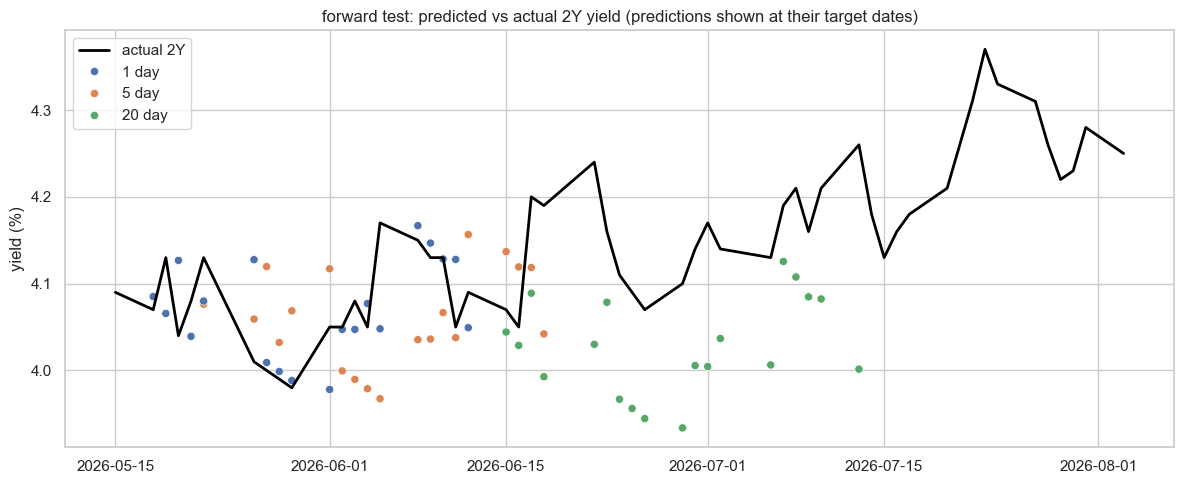

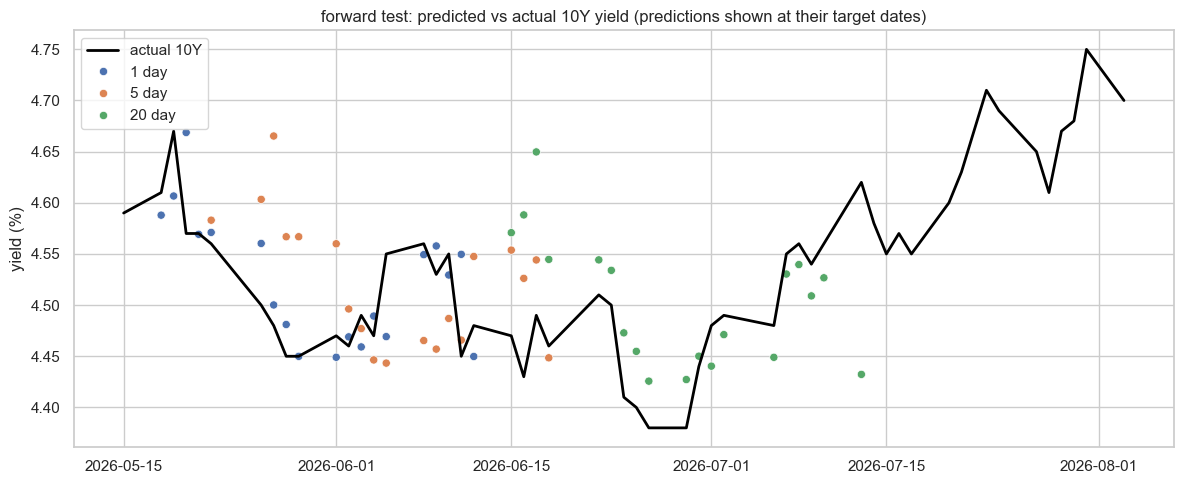

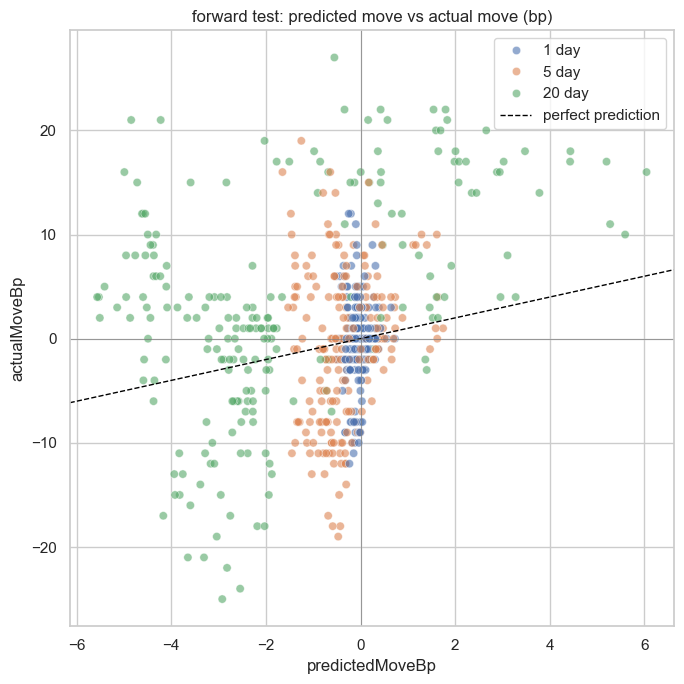

figures saved to the figures folder


In [17]:
import seaborn as sns

os.makedirs("../figures", exist_ok=True)
sns.set_theme(style="whitegrid")

#collect forward predictions in long form for plotting
plotRows = []
for w in range(len(forwardStarts)):
    start = forwardStarts[w]
    for j in range(len(horizons)):
        for i in range(len(matList)):
            plotRows.append({
                "targetDate": modelDf.index[start + horizons[j]],
                "horizon": str(horizons[j]) + " day",
                "maturity": matList[i],
                "predictedYield": forwardResults["EWA Ensemble"][w][j][i],
                "actualYield": forwardResults["actual"][w][j][i],
                "predictedMoveBp": 100 * (forwardResults["EWA Ensemble"][w][j][i] - forwardResults["current"][w][j][i]),
                "actualMoveBp": 100 * (forwardResults["actual"][w][j][i] - forwardResults["current"][w][j][i]),
            })
plotDf = pd.DataFrame(plotRows)

#line plots: actual path vs predictions placed at their target dates
for mat in ["2Y", "10Y"]:
    plt.figure(figsize=(12, 5))
    forwardActual = dfFull[mat].loc[dfFull.index > oldLastDate]
    plt.plot(forwardActual.index, forwardActual.to_numpy(), color="black", linewidth=2, label="actual " + mat)
    matPlot = plotDf[plotDf["maturity"] == mat]
    sns.scatterplot(data=matPlot, x="targetDate", y="predictedYield", hue="horizon", s=35)
    plt.title("forward test: predicted vs actual " + mat + " yield (predictions shown at their target dates)")
    plt.ylabel("yield (%)")
    plt.xlabel("")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../figures/forward_test_predicted_vs_actual_" + mat + ".png", dpi=150)
    plt.show()

#scatter: predicted move vs actual move, diagonal = perfect
plt.figure(figsize=(7, 7))
sns.scatterplot(data=plotDf, x="predictedMoveBp", y="actualMoveBp", hue="horizon", alpha=0.6)
plt.axline((0, 0), slope=1, color="black", linestyle="--", linewidth=1, label="perfect prediction")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("forward test: predicted move vs actual move (bp)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/forward_test_predicted_vs_actual_moves.png", dpi=150)
plt.show()
print("figures saved to the figures folder")

#### Expanded validation: per-horizon windows, maximum use of the new data

- the 19-window forward test above shares one origin list across horizons and looks targets up inside the feature table, both of which waste usable new data
- this section uses per-horizon origin lists and looks targets up in the full yield calendar (targets only need yields), giving 39 / 39 / 34 validation windows at 1 / 5 / 20 days
- origins are capped by T5YIE availability (2026-07-13); the last 20 day target lands on 2026-08-03, the final day of maturities_full
- pipeline stays frozen (decay, hsmm, spillover lag, tuned settings); ridge and residual coefficients refit walk-forward on realized data only; the EWA weight is warmed up through the test period per horizon and only ever absorbs realized outcomes

In [18]:
#full yield calendar for target lookups (targets only need yields)
fullDays = list(dfFull.index)
fullPos = {}
for i in range(len(fullDays)):
    fullPos[fullDays[i]] = i

#modelDf position lookup for feature rows
modelPos = {}
for i in range(len(modelDf.index)):
    modelPos[modelDf.index[i]] = i

#per-horizon validation origin lists: after the old sample end, features must exist
#(the date is in modelDf), and the target must exist in the full yield calendar
valStartsByH = {}
for horizon in horizons:
    starts = []
    for date in modelDf.index:
        if date > oldLastDate and fullPos[date] + horizon < len(fullDays):
            starts.append(date)
    valStartsByH[horizon] = starts
    print("h=", horizon, ": ", len(starts), " validation windows, origins ",
          starts[0].date(), " to ", starts[-1].date(),
          ", last target ", fullDays[fullPos[starts[-1]] + horizon].date())

h= 1 :  39  validation windows, origins  2026-05-15  to  2026-07-13 , last target  2026-07-14
h= 5 :  39  validation windows, origins  2026-05-15  to  2026-07-13 , last target  2026-07-20
h= 20 :  34  validation windows, origins  2026-05-15  to  2026-07-06 , last target  2026-08-03


In [19]:
#per-horizon evaluation: warm the EWA through the test period, then forecast
#every validation origin. targets come from the full yield calendar.
valRows = []

for horizon in horizons:
    settings = bestSettings[horizon]

    #combined date list: test period origins then validation origins
    testDates = []
    for start in windowStarts:
        testDates.append(modelDf.index[start])
    allDates = testDates + valStartsByH[horizon]

    state = {"varxLossSum": 0.0, "walkLossSum": 0.0, "normSum": 0.0, "normCount": 0.0, "absorbed": 0}
    history = []

    for stepIndex in range(len(allDates)):
        date = allDates[stepIndex]
        mPos = modelPos[date]
        fPos = fullPos[date]

        varxYields = varxForecast(horizon, mPos, settings["window"], settings["alpha"])
        walkYields = dfFull.iloc[fPos].to_numpy(dtype=float)
        actualYields = dfFull.iloc[fPos + horizon].to_numpy(dtype=float)

        #absorb every past window whose outcome is realized (index + h <= now)
        while state["absorbed"] + horizon <= stepIndex:
            past = history[state["absorbed"]]
            varxLoss = np.mean((past[2] - past[0]) ** 2)
            walkLoss = np.mean((past[2] - past[1]) ** 2)
            state["normSum"] = ewaDiscount * state["normSum"] + walkLoss
            state["normCount"] = ewaDiscount * state["normCount"] + 1.0
            normalizer = state["normSum"] / state["normCount"]
            if normalizer < 1e-6:
                normalizer = 1e-6
            state["varxLossSum"] = ewaDiscount * state["varxLossSum"] + varxLoss / normalizer
            state["walkLossSum"] = ewaDiscount * state["walkLossSum"] + walkLoss / normalizer
            state["absorbed"] = state["absorbed"] + 1

        varxScore = np.exp(-ewaEta * state["varxLossSum"])
        walkScore = np.exp(-ewaEta * state["walkLossSum"])
        weight = varxScore / (varxScore + walkScore)
        weight = (1.0 - ewaFloor) * weight + ewaFloor * 0.5

        ewaYields = weight * varxYields + (1.0 - weight) * walkYields
        history.append([varxYields, walkYields, actualYields])

        #store only validation windows
        if date > oldLastDate:
            for i in range(len(matList)):
                for pair in [["Random Walk", walkYields], ["VARX", varxYields], ["EWA Ensemble", ewaYields]]:
                    valRows.append({
                        "origin_date": date,
                        "target_date": fullDays[fPos + horizon],
                        "horizon": horizon,
                        "maturity": matList[i],
                        "model": pair[0],
                        "ewa_weight": weight,
                        "origin_yield": walkYields[i],
                        "actual_yield": actualYields[i],
                        "predicted_yield": pair[1][i],
                    })

    print("finished horizon ", horizon)

valDf = pd.DataFrame(valRows)
valDf.to_csv("../data/generated/final2_results/validation_forecasts.csv", index=False)
print("saved validation_forecasts.csv with ", len(valDf), " rows")

finished horizon  1


finished horizon  5


finished horizon  20
saved validation_forecasts.csv with  3696  rows


In [20]:
#validation error calculations, baseline print format
print("==============================")
print("EXPANDED VALIDATION ERRORS (39 / 39 / 34 windows, frozen pipeline)")
print("==============================")
for modelName in ["Random Walk", "VARX", "EWA Ensemble"]:
    print("Model: ", modelName)
    for horizon in horizons:
        rows = valDf[(valDf["model"] == modelName) & (valDf["horizon"] == horizon)]
        errors = 100 * (rows["predicted_yield"] - rows["actual_yield"]).to_numpy()
        rmse = np.sqrt(np.mean(errors ** 2))
        mae = np.mean(np.abs(errors))

        predictedSign = np.sign((rows["predicted_yield"] - rows["origin_yield"]).to_numpy())
        actualSign = np.sign((rows["actual_yield"] - rows["origin_yield"]).to_numpy())
        scorable = (predictedSign != 0) & (actualSign != 0)
        if scorable.sum() > 0:
            directionalAccuracy = 100 * np.mean(predictedSign[scorable] == actualSign[scorable])
        else:
            directionalAccuracy = np.nan
        nonzero = actualSign[actualSign != 0]
        baseRate = 100 * max(np.mean(nonzero > 0), np.mean(nonzero < 0))

        print(f"Horizon: {horizon} day, rmse: {rmse}, MAE: {mae}, Directional Accuracy: {directionalAccuracy} %, base rate: {baseRate} % ")
    print()

print("DM tests, EWA vs Random Walk (small samples, low power)")
for horizon in horizons:
    ewaRows = valDf[(valDf["model"] == "EWA Ensemble") & (valDf["horizon"] == horizon)]
    rwRows = valDf[(valDf["model"] == "Random Walk") & (valDf["horizon"] == horizon)]
    ewaLoss = ((100 * (ewaRows["predicted_yield"] - ewaRows["actual_yield"])) ** 2).groupby(ewaRows["origin_date"]).mean().sort_index()
    rwLoss = ((100 * (rwRows["predicted_yield"] - rwRows["actual_yield"])) ** 2).groupby(rwRows["origin_date"]).mean().sort_index()
    statistic, pValue = dieboldMariano(ewaLoss.to_numpy(), rwLoss.to_numpy(), horizon)
    print("h=", horizon, " DM: ", round(statistic, 2), " p: ", round(pValue, 4))

print()
print("weighted directional accuracy, EWA Ensemble (1bp threshold, 0.5bp cost)")
for horizon in horizons:
    rows = valDf[(valDf["model"] == "EWA Ensemble") & (valDf["horizon"] == horizon)]
    predictedMove = 100 * (rows["predicted_yield"] - rows["origin_yield"]).to_numpy()
    actualMove = 100 * (rows["actual_yield"] - rows["origin_yield"]).to_numpy()
    pnl = 0.0
    available = 0.0
    trades = 0
    for t in range(len(predictedMove)):
        if abs(predictedMove[t]) >= thresholdBp:
            pnl = pnl + np.sign(predictedMove[t]) * actualMove[t] - costBp
            available = available + abs(actualMove[t])
            trades = trades + 1
    if available > 0:
        capture = pnl / available
        print("Horizon: ", horizon, " day, weighted DA: ", round((1.0 + capture) / 2.0, 4),
              " capture: ", round(capture, 4), " trades: ", trades, " net pnl bp: ", round(pnl, 1))
    else:
        print("Horizon: ", horizon, " day, no trades cleared the threshold")

EXPANDED VALIDATION ERRORS (39 / 39 / 34 windows, frozen pipeline)
Model:  Random Walk
Horizon: 1 day, rmse: 4.160251471689219, MAE: 3.041958041958043, Directional Accuracy: nan %, base rate: 52.732240437158474 % 
Horizon: 5 day, rmse: 7.509279418777633, MAE: 5.951048951048949, Directional Accuracy: nan %, base rate: 53.46534653465347 % 
Horizon: 20 day, rmse: 13.772502248386752, MAE: 11.1524064171123, Directional Accuracy: nan %, base rate: 78.41530054644808 % 

Model:  VARX
Horizon: 1 day, rmse: 4.1576619600306, MAE: 3.072195314573694, Directional Accuracy: 46.72131147540984 %, base rate: 52.732240437158474 % 
Horizon: 5 day, rmse: 7.635597756385477, MAE: 6.018453307199103, Directional Accuracy: 53.46534653465347 %, base rate: 53.46534653465347 % 
Horizon: 20 day, rmse: 15.186003174404783, MAE: 12.277737621313193, Directional Accuracy: 43.169398907103826 %, base rate: 78.41530054644808 % 

Model:  EWA Ensemble
Horizon: 1 day, rmse: 4.155491124130256, MAE: 3.058241545986598, Direction

#### Expanded validation figures

- predicted vs actual yield paths for 2Y and 10Y over the full validation span, predictions at their target dates
- per-horizon predicted vs actual move scatter with fitted relationship and correlation
- saved to the figures folder as validation_*

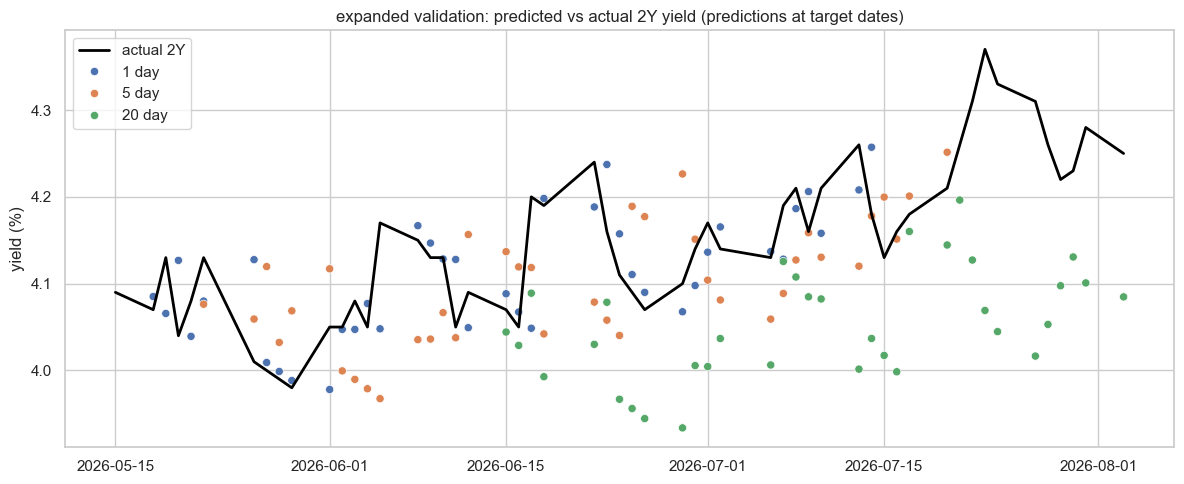

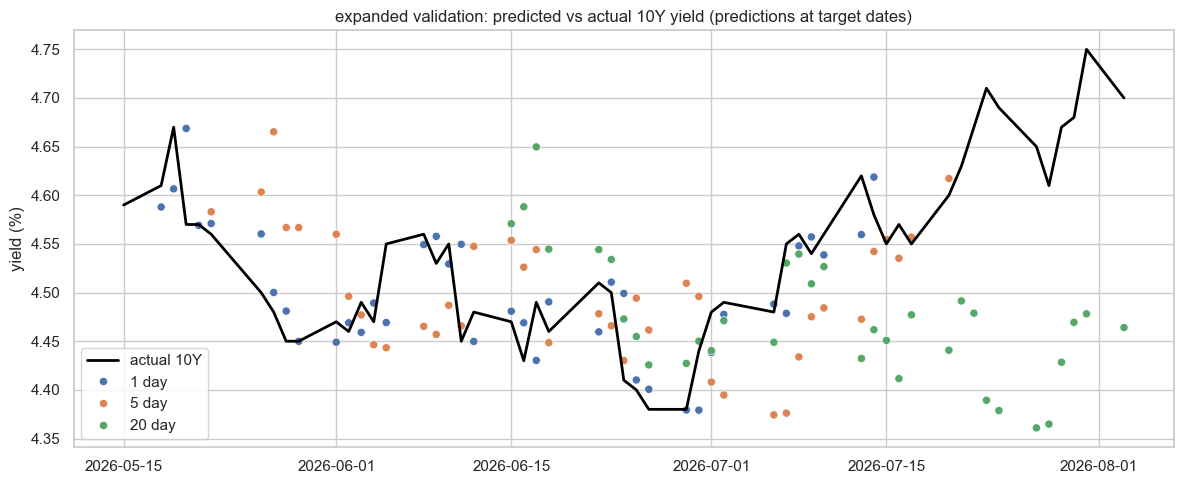

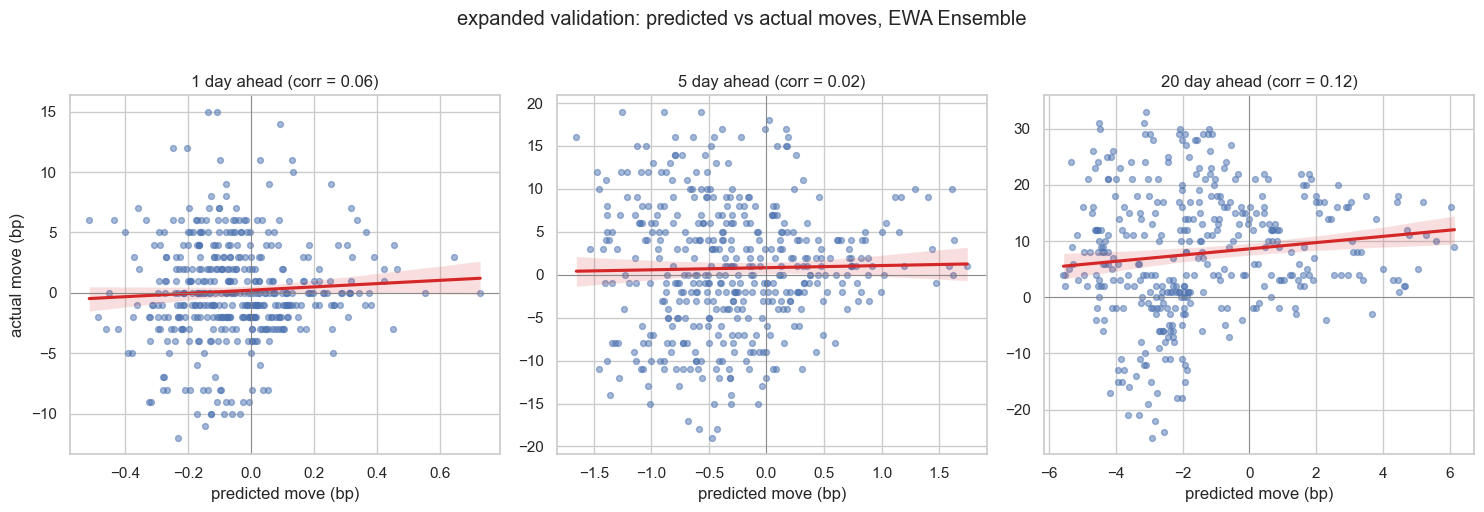

validation figures saved


In [21]:
valPlot = valDf[valDf["model"] == "EWA Ensemble"].copy()
valPlot["predictedMoveBp"] = 100 * (valPlot["predicted_yield"] - valPlot["origin_yield"])
valPlot["actualMoveBp"] = 100 * (valPlot["actual_yield"] - valPlot["origin_yield"])
valPlot["horizonLabel"] = valPlot["horizon"].astype(str) + " day"

for mat in ["2Y", "10Y"]:
    plt.figure(figsize=(12, 5))
    pathActual = dfFull[mat].loc[dfFull.index > oldLastDate]
    plt.plot(pathActual.index, pathActual.to_numpy(), color="black", linewidth=2, label="actual " + mat)
    matPlot = valPlot[valPlot["maturity"] == mat]
    sns.scatterplot(data=matPlot, x="target_date", y="predicted_yield", hue="horizonLabel", s=35)
    plt.title("expanded validation: predicted vs actual " + mat + " yield (predictions at target dates)")
    plt.ylabel("yield (%)")
    plt.xlabel("")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../figures/validation_predicted_vs_actual_" + mat + ".png", dpi=150)
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
horizonList = [1, 5, 20]
for a in range(3):
    sub = valPlot[valPlot["horizon"] == horizonList[a]]
    corr = np.corrcoef(sub["predictedMoveBp"], sub["actualMoveBp"])[0, 1]
    sns.regplot(data=sub, x="predictedMoveBp", y="actualMoveBp", ax=axes[a],
                scatter_kws={"alpha": 0.5, "s": 18}, line_kws={"color": "tab:red"})
    axes[a].axhline(0, color="gray", linewidth=0.6)
    axes[a].axvline(0, color="gray", linewidth=0.6)
    axes[a].set_title(str(horizonList[a]) + " day ahead (corr = " + str(round(corr, 2)) + ")")
    axes[a].set_xlabel("predicted move (bp)")
    axes[a].set_ylabel("actual move (bp)" if a == 0 else "")
fig.suptitle("expanded validation: predicted vs actual moves, EWA Ensemble", y=1.02)
plt.tight_layout()
plt.savefig("../figures/validation_predicted_vs_actual_moves.png", dpi=150, bbox_inches="tight")
plt.show()
print("validation figures saved")